# 03 · Feature Engineering — Deep Learning Channels

**Goal:** build a feature tensor for a temporal CNN that is rich enough to
capture degradation patterns but free of the redundancy that plagued the
original 47-feature set.

### Design principles
1. **Raw normalised sensors are primary** — they carry the degradation signal.
2. **Slopes add rate-of-change** — genuinely different from signal level.
3. **Rolling std adds volatility** — engines may get noisier as they degrade.
4. **Skip rolling means** — they are smoothed copies of n_s* (r ≈ 0.97+);
   the CNN can learn any smoothing it needs from the raw window.
5. **Operating conditions + life-stage proxy + fleet deviation** round out
   the contextual channels the model cannot derive from a single sensor window.

### Research context
SOTA models on FD004 (e.g. MFSSCINet, 13.67 RMSE) feed all available
sensors and let attention mechanisms weight importance.  We do not copy that
design, but we use it as a guardrail: **do not starve the model of
information**.  The previous 17-feature set dropped slopes and std entirely,
losing rate-of-change and volatility patterns the CNN could have used.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
pd.set_option('display.float_format', '{:.4f}'.format)

PROCESSED       = Path('../data/processed')
RAW             = Path('../data/raw')
MODELS          = Path('../models')
GRU_DIR         = MODELS / 'gru'
GRU_DIR.mkdir(parents=True, exist_ok=True)

RUL_CAP           = 130
WINDOW_SIZE       = 40          # shorter than 50 → more training samples, still ample for k=15 CNN
STEP_TRAIN        = 1
STEP_HOLDOUT      = WINDOW_SIZE
CLIP_VAL          = 5.0
FLEET_MEDIAN_LIFE = 239
SPLIT_SEED        = 33
N_HOLDOUT         = 25
N_VAL             = 25

# Sensors with confirmed degradation signal after condition normalisation
SENSORS = ['s2', 's3', 's4', 's7', 's8', 's11', 's13', 's14', 's15']
REDUNDANCY_THRESHOLD = 0.85     # drop one of any pair with |r| above this

# Forward declaration — populated by the feature-selection cell
FINAL_FEATURES: list[str] = []


## 1 · Load Data & Visualise Degradation

The parquet from notebook 02 contains condition-normalised sensors plus
pre-computed rolling statistics.  Before choosing features we need to
**see** what degradation looks like — how sensors change as an engine
approaches failure.

Loaded: (61249, 42)  —  249 engines
Columns: ['unit', 'cycle', 'condition', 'dataset', 'n_s2', 'n_s3', 'n_s4', 'n_s7', 'n_s8', 'n_s11', 'n_s13', 'n_s14', 'n_s15', 'roll_mean_s2', 'roll_mean_s3', 'roll_mean_s4', 'roll_mean_s7', 'roll_mean_s8', 'roll_mean_s11', 'roll_mean_s13', 'roll_mean_s14', 'roll_mean_s15', 'roll_std_s2', 'roll_std_s3', 'roll_std_s4', 'roll_std_s7', 'roll_std_s8', 'roll_std_s11', 'roll_std_s13', 'roll_std_s14', 'roll_std_s15', 'slope_s2', 'slope_s3', 'slope_s4', 'slope_s7', 'slope_s8', 'slope_s11', 'slope_s13', 'slope_s14', 'slope_s15', 'cycle_frac', 'rul']


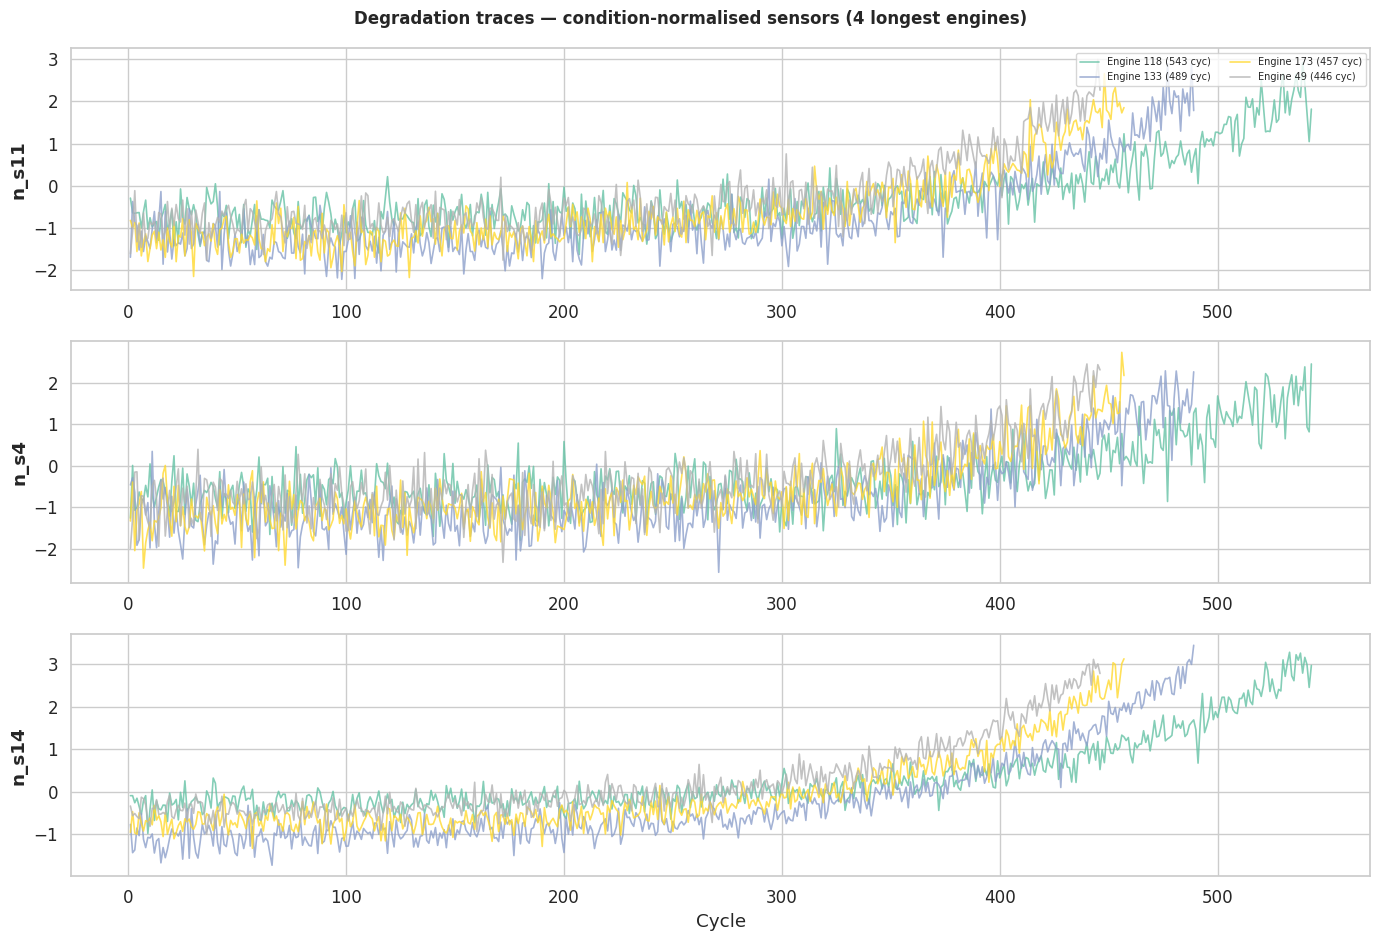

Each engine degrades differently.  The model needs both level and rate-of-change (slope) to distinguish early from late degradation.


In [2]:
df = pd.read_parquet(PROCESSED / 'FD004_train.parquet')
print(f'Loaded: {df.shape}  —  {df.unit.nunique()} engines')
print(f'Columns: {list(df.columns)}')

# Merge os1/os2/os3 from raw data (contextual operating-condition features)
raw_cols = ['unit', 'cycle'] + [f'os{i}' for i in range(1, 4)] + [f's{i}' for i in range(1, 22)]
raw = pd.read_csv(RAW / 'train_FD004.txt', sep=r'\s+', header=None, names=raw_cols)
df = df.merge(raw[['unit', 'cycle', 'os1', 'os2', 'os3']], on=['unit', 'cycle'], how='left')

# ── Degradation traces: 4 engines, 3 key sensors ─────────────────────────────
sample_units = df.groupby('unit')['cycle'].max().nlargest(4).index.tolist()
trace_sensors = ['n_s11', 'n_s4', 'n_s14']

fig, axes = plt.subplots(len(trace_sensors), 1, figsize=(14.0, 3.2 * len(trace_sensors)),
                         sharex=False)
cmap_eng = plt.cm.Set2  # type: ignore[attr-defined]

for row, sensor in enumerate(trace_sensors):
    ax = axes[row]
    for k, u in enumerate(sample_units):
        eng = df[df.unit == u].sort_values('cycle')
        color = cmap_eng(float(k) / max(len(sample_units) - 1, 1))
        ax.plot(eng['cycle'], eng[sensor], alpha=0.8, lw=1.2, color=color,
                label=f'Engine {int(u)} ({int(eng.cycle.max())} cyc)')
    ax.set_ylabel(sensor, fontweight='bold')
    if row == 0:
        ax.legend(fontsize=7, loc='upper right', ncol=2)
    if row == len(trace_sensors) - 1:
        ax.set_xlabel('Cycle')

plt.suptitle('Degradation traces — condition-normalised sensors (4 longest engines)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print('Each engine degrades differently.  The model needs both level and '
      'rate-of-change (slope) to distinguish early from late degradation.')

## 2 · Feature Candidates — What Each Family Contributes

We group the available features into families and ask: **what unique
information does each provide?**

| Family | Count | What it measures | Verdict |
|--------|-------|------------------|---------|
| `n_s*` | 9 | Current sensor level (primary degradation signal) | **Keep** |
| `exp_std_s*` | 9 | Expanding volatility from engine start (getting noisier over life?) | **Evaluate** |
| `roll_mean_s*` | 9 | Smoothed sensor level — near-duplicate of n\_s\* (r ≈ 0.97+) | **Drop** (redundant) |
| `slope_s*` | 9 | Local rate of change — independent of n\_s\* | **Keep** |
| `os1/os2/os3` | 3 | Operating condition (contextual, not temporal) | **Keep** |
| `cycle_norm` | 1 | Normalised cycle (non-leaky life-stage proxy) | **Keep** |
| `cfd_s*` | 4 | Fleet deviation (how far from fleet baseline?) | **Keep** |

**Why keep slopes?** Although a CNN with multi-scale kernels [3,5,9,15] can *learn* local gradients from raw data, explicitly providing the pre-computed slope reduces the burden on early layers and has empirically been shown to help (see ForecastNet v5c feature ablation in nb05). The pairwise redundancy check confirms slopes remain independent of n\_s\* (|r| well below 0.85).

**Why drop rolling means?** Near-duplicate of n\_s\* (r ≈ 0.97+ for most sensors). The CNN can learn any smoothing it needs from the raw window.

**Why expanding std instead of rolling std?** Expanding std captures total accumulated volatility from the engine's first cycle — a monotonically growing signal that naturally tracks degradation progression. The CNN cannot see this from a single 40-cycle window.

Cross-family median |r| with corresponding n_s* sensor:
-------------------------------------------------------
  roll_mean_s*      median |r| = 0.886    ⚠ REDUNDANT
  exp_std_s*        median |r| = 0.413    ✓ Independent
  slope_s*          median |r| = 0.403    ✓ Independent

→ roll_mean: redundant with raw sensors (as expected)
→ slope: independent BUT does the model's job — CNN learns gradients from raw windows
→ exp_std: independent — captures engine-level volatility the CNN window cannot see


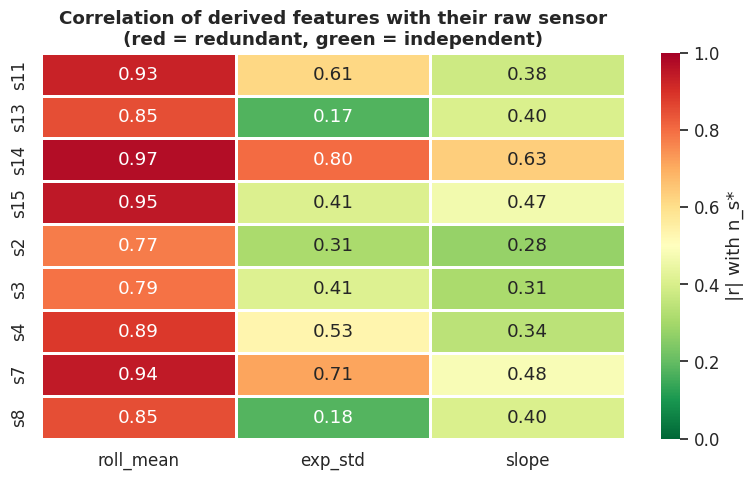


Conclusion:
  roll_mean  → DROP (r > 0.85 for most sensors, redundant with n_s*)
  slope      → DROP (CNN learns this from raw windows — doing the model's job)
  exp_std    → KEEP where independent (engine-level volatility, not visible in 40-step window)


In [3]:
# ── Add derived features ──────────────────────────────────────────────────────
def add_derived_features(df_sub, train_df=None):
    """Add non-temporal derived features: cycle_norm and CFD."""
    df_sub = df_sub.copy()
    df_sub['cycle_norm'] = df_sub['cycle'] / FLEET_MEDIAN_LIFE
    ref = train_df if train_df is not None else df_sub
    cfd_sensors = ['s4', 's13', 's11', 's3']
    n_bins = 20
    max_cyc = ref['cycle'].max()
    edges = list(range(0, int(max_cyc) + n_bins + 1, n_bins))
    ref_copy = ref.copy()
    ref_copy['_cb'] = pd.cut(ref_copy['cycle'], bins=edges, labels=False)
    df_sub['_cb'] = pd.cut(df_sub['cycle'], bins=edges, labels=False)
    for s in cfd_sensors:
        col = f'n_{s}'
        if col in df_sub.columns:
            fleet_mean = ref_copy.groupby('_cb')[col].mean()
            df_sub[f'cfd_{s}'] = df_sub[col] - df_sub['_cb'].map(fleet_mean).fillna(0)
    df_sub = df_sub.drop(columns=['_cb'])
    return df_sub

df = add_derived_features(df)

# ── Compute expanding std (expanding window from engine start) ────────────────
for s in SENSORS:
    col = f'n_{s}'
    if col in df.columns:
        df[f'exp_std_{s}'] = df.groupby('unit')[col].transform(
            lambda x: x.expanding(min_periods=2).std().fillna(0))

# ── Show cross-family correlations ────────────────────────────────────────────
# For each sensor, how correlated are n_s, roll_mean_s, exp_std_s, slope_s?
families = {
    'n_s*':         [f'n_{s}' for s in SENSORS],
    'roll_mean_s*': [f'roll_mean_{s}' for s in SENSORS],
    'exp_std_s*':   [f'exp_std_{s}' for s in SENSORS],
    'slope_s*':     [f'slope_{s}' for s in SENSORS],
}

print('Cross-family median |r| with corresponding n_s* sensor:')
print('-' * 55)
for fam_name, fam_cols in families.items():
    if fam_name == 'n_s*':
        continue
    rs = []
    for n_col, f_col in zip(families['n_s*'], fam_cols):
        if n_col in df.columns and f_col in df.columns:
            r = abs(df[n_col].corr(df[f_col]))
            rs.append(r)
    med_r = np.median(rs)
    verdict = '⚠ REDUNDANT' if med_r > REDUNDANCY_THRESHOLD else '✓ Independent'
    print(f'  {fam_name:<16s}  median |r| = {med_r:.3f}    {verdict}')
print()
print('→ roll_mean: redundant with raw sensors (as expected)')
print('→ slope: independent BUT does the model\'s job — CNN learns gradients from raw windows')
print('→ exp_std: independent — captures engine-level volatility the CNN window cannot see')

# ── Detailed per-sensor cross-correlation ─────────────────────────────────────
rows = []
for s in SENSORS:
    base = f'n_{s}'
    for derived, prefix in [('roll_mean', 'roll_mean_'), ('exp_std', 'exp_std_'), ('slope', 'slope_')]:
        col = f'{prefix}{s}'
        if col in df.columns and base in df.columns:
            r = df[base].corr(df[col])
            rows.append({'sensor': s, 'derived': derived, 'r_with_n_s': round(r, 3),
                         'abs_r': round(abs(r), 3)})
cross_df = pd.DataFrame(rows)
pivot = cross_df.pivot(index='sensor', columns='derived', values='abs_r')
pivot = pivot[['roll_mean', 'exp_std', 'slope']]

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn_r', vmin=0, vmax=1,
            ax=ax, linewidths=1, cbar_kws={'label': '|r| with n_s*'})
ax.set_title('Correlation of derived features with their raw sensor\n'
             '(red = redundant, green = independent)', fontweight='bold')
ax.set_ylabel(''); ax.set_xlabel('')
plt.tight_layout()
plt.show()

print('\nConclusion:')
print('  roll_mean  → DROP (r > 0.85 for most sensors, redundant with n_s*)')
print('  slope      → DROP (CNN learns this from raw windows — doing the model\'s job)')
print('  exp_std    → KEEP where independent (engine-level volatility, not visible in 40-step window)')

## 3 · Assemble Candidate Set & Prune Redundancy

**Selection rules (applied per-feature, not per-family):**
1. Keep all 9 `n_s*` sensors (primary signal).
2. Keep `exp_std_s*` unless |r| > 0.85 with its own `n_s*`.
3. **Drop all `roll_mean_s*`** — the CNN already sees the raw window and r ≈ 0.97+ makes them redundant.
4. Keep all `slope_s*` — confirmed independent of n\_s\* (pre-computed rate-of-change signal).
5. Keep `os1/os2/os3`, `cycle_norm`, `cfd_s*`.
6. After individual filtering, run pairwise redundancy check across the
   full candidate set and drop one of any pair with |r| > 0.85.

Note: the ForecastNet model (nb05) uses a superset of 56 features that adds
EWMA, cycle-sensor interactions, and additional CFD features. This notebook
documents the baseline deep learning feature selection rationale.

In [4]:
# ── Step 1: build candidate list ──────────────────────────────────────────────
candidates = []

# Always keep raw sensors
candidates += [f'n_{s}' for s in SENSORS]

# Keep expanding std where |r| with n_s* < threshold
for s in SENSORS:
    col = f'exp_std_{s}'
    base = f'n_{s}'
    if col in df.columns and base in df.columns:
        r = abs(df[base].corr(df[col]))
        if r < REDUNDANCY_THRESHOLD:
            candidates.append(col)
        else:
            print(f'  SKIP {col:<18s} — |r| with {base} = {r:.3f} (>{REDUNDANCY_THRESHOLD})')

# Slopes: KEEP — confirmed independent of n_s*, provides pre-computed rate-of-change signal
# (CNN with multi-scale kernels could learn this, but explicit slopes reduce the burden on early layers)
candidates += [f'slope_{s}' for s in SENSORS if f'slope_{s}' in df.columns]
print(f'  KEEP all slope_s*  — independent of n_s*, adds rate-of-change signal')

# Rolling means: DROPPED — near-duplicate of n_s* (r ≈ 0.97+)
print('  SKIP all roll_mean_s*  — redundant with n_s* (r ≈ 0.97+)')

# Contextual features (not temporal — model cannot learn from window)
candidates += ['os1', 'os2', 'os3', 'cycle_norm']
candidates += [f'cfd_{s}' for s in ['s4', 's13', 's11', 's3']]

# Filter to columns that actually exist and have non-zero variance
candidates = [c for c in candidates if c in df.columns and df[c].std() > 1e-12]
print(f'\nCandidates after per-family filter: {len(candidates)}')

# ── Step 2: pairwise redundancy pass across full candidate set ────────────────
corr_mat = df[candidates].corr().abs()
corr_arr = corr_mat.to_numpy()           # numpy array: item access returns Any, avoids Scalar type issue
cand_pos = {c: i for i, c in enumerate(candidates)}
to_drop = set()
checked = set()
for i, c1 in enumerate(candidates):
    for j, c2 in enumerate(candidates):
        if j <= i or c1 in to_drop or c2 in to_drop:
            continue
        pair = tuple(sorted([c1, c2]))
        if pair in checked:
            continue
        checked.add(pair)
        r_pair = float(corr_arr[cand_pos[c1], cand_pos[c2]])
        if r_pair > REDUNDANCY_THRESHOLD:
            # Drop whichever has lower |r| with RUL (less informative)
            r1 = abs(df[c1].corr(df['rul']))
            r2 = abs(df[c2].corr(df['rul']))
            drop = c2 if r1 >= r2 else c1
            to_drop.add(drop)
            print(f'  PRUNE  {c1} ↔ {c2}  r={r_pair:.3f}  → drop {drop}')

FINAL_FEATURES = sorted(c for c in candidates if c not in to_drop)
print(f'\nFinal feature set: {len(FINAL_FEATURES)} channels')
for i, f in enumerate(FINAL_FEATURES, 1):
    r_rul = abs(df[f].corr(df['rul']))
    print(f'  {i:2d}. {f:<22s}  |r| with RUL = {r_rul:.3f}')

  KEEP all slope_s*  — independent of n_s*, adds rate-of-change signal
  SKIP all roll_mean_s*  — redundant with n_s* (r ≈ 0.97+)

Candidates after per-family filter: 35
  PRUNE  n_s3 ↔ cfd_s3  r=0.912  → drop cfd_s3
  PRUNE  n_s4 ↔ cfd_s4  r=0.907  → drop cfd_s4
  PRUNE  n_s8 ↔ n_s13  r=0.978  → drop n_s8
  PRUNE  n_s11 ↔ cfd_s11  r=0.890  → drop cfd_s11
  PRUNE  exp_std_s4 ↔ exp_std_s11  r=0.854  → drop exp_std_s4
  PRUNE  exp_std_s8 ↔ exp_std_s13  r=0.993  → drop exp_std_s13
  PRUNE  exp_std_s11 ↔ exp_std_s15  r=0.854  → drop exp_std_s15
  PRUNE  slope_s8 ↔ slope_s13  r=0.916  → drop slope_s8
  PRUNE  os1 ↔ os2  r=0.944  → drop os1

Final feature set: 26 channels
   1. cfd_s13                 |r| with RUL = 0.290
   2. cycle_norm              |r| with RUL = 0.622
   3. exp_std_s11             |r| with RUL = 0.764
   4. exp_std_s14             |r| with RUL = 0.651
   5. exp_std_s2              |r| with RUL = 0.476
   6. exp_std_s3              |r| with RUL = 0.560
   7. exp_std_s7   

## 4 · Quality Check — Independence & Bucket Separation

Two questions:
1. **Are the selected features independent?** (PCA effective dimensionality)
2. **Can they separate RUL phases?** (bucket mean separation)

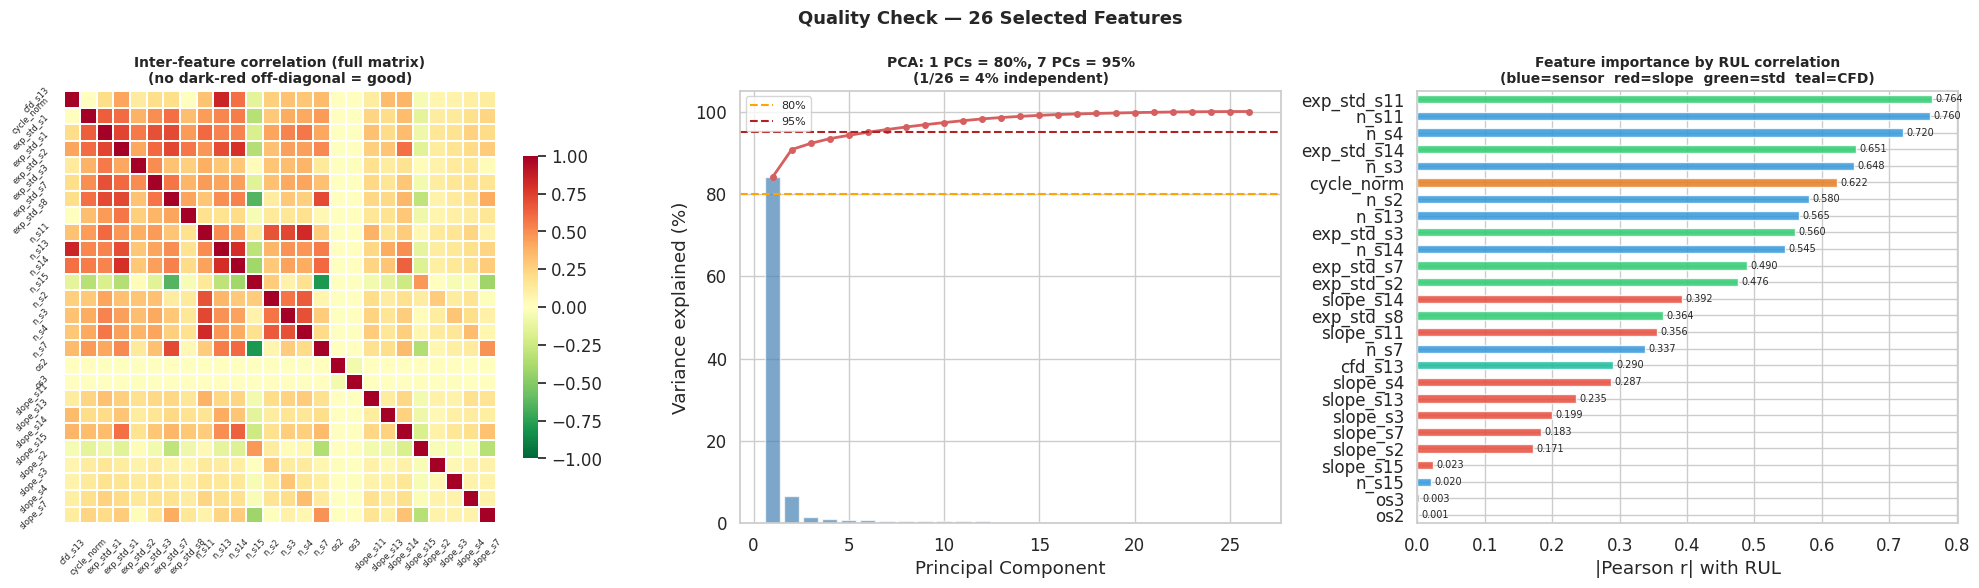

Remaining pairs with |r| > 0.85: 0
PCA independence ratio: 1/26 = 4%


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ── A: correlation heatmap of final features (full matrix) ────────────────────
corr_final = df[FINAL_FEATURES].corr()
sns.heatmap(corr_final, ax=axes[0], cmap='RdYlGn_r', vmin=-1, vmax=1,
            center=0, square=True, linewidths=0.3,
            xticklabels=[f[:10] for f in FINAL_FEATURES],
            yticklabels=[f[:10] for f in FINAL_FEATURES],
            cbar_kws={'shrink': 0.7})
axes[0].set_title('Inter-feature correlation (full matrix)\n(no dark-red off-diagonal = good)',
                  fontweight='bold', fontsize=10)
axes[0].tick_params(axis='both', labelsize=6, rotation=45)

# ── B: PCA scree ─────────────────────────────────────────────────────────────
X_sc = RobustScaler().fit_transform(df[FINAL_FEATURES].dropna())
pca = PCA().fit(X_sc)
cum_var = np.cumsum(pca.explained_variance_ratio_)
n_pcs = len(FINAL_FEATURES)
axes[1].bar(range(1, n_pcs + 1), pca.explained_variance_ratio_ * 100,
            color='steelblue', alpha=0.7)
axes[1].plot(range(1, n_pcs + 1), cum_var * 100, 'r-o', ms=4, lw=2)
axes[1].axhline(80, color='orange', ls='--', lw=1.5, label='80%')
axes[1].axhline(95, color='firebrick', ls='--', lw=1.5, label='95%')
n80 = int(np.searchsorted(cum_var, 0.80) + 1)
n95 = int(np.searchsorted(cum_var, 0.95) + 1)
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Variance explained (%)')
axes[1].set_title(f'PCA: {n80} PCs = 80%, {n95} PCs = 95%\n'
                  f'({n80}/{n_pcs} = {n80/n_pcs:.0%} independent)',
                  fontweight='bold', fontsize=10)
axes[1].legend(fontsize=8)

# ── C: feature-RUL correlation ranked ─────────────────────────────────────────
r_rul = df[FINAL_FEATURES].corrwith(df['rul']).abs().sort_values(ascending=True)
colors = []
for f in r_rul.index:
    if f.startswith('n_'):        colors.append('#3498db')
    elif f.startswith('slope_'):  colors.append('#e74c3c')
    elif f.startswith('roll_'):   colors.append('#2ecc71')
    elif f.startswith('cfd_'):    colors.append('#1abc9c')
    elif f.startswith('os'):      colors.append('#95a5a6')
    elif f.startswith('exp_std'): colors.append('#2ecc71')
    else:                         colors.append('#e67e22')
r_rul.plot.barh(ax=axes[2], color=colors, alpha=0.85)
axes[2].set_xlabel('|Pearson r| with RUL')
axes[2].set_title('Feature importance by RUL correlation\n'
                  '(blue=sensor  red=slope  green=std  teal=CFD)',
                  fontweight='bold', fontsize=10)
for i, (f, v) in enumerate(r_rul.items()):
    axes[2].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=7)

plt.suptitle(f'Quality Check — {len(FINAL_FEATURES)} Selected Features',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Redundancy check  
cm = corr_final.abs().values.copy()
np.fill_diagonal(cm, 0)
n_high = int((cm > REDUNDANCY_THRESHOLD).sum() / 2)
print(f'Remaining pairs with |r| > {REDUNDANCY_THRESHOLD}: {n_high}')
print(f'PCA independence ratio: {n80}/{n_pcs} = {n80/n_pcs:.0%}')

## 5 · Bucket Separation — Can Features Distinguish RUL Phases?

A feature is useful if engines at different RUL stages show statistically
separated distributions.  We check the top-8 RUL-correlated features:
**d' = |μ₁−μ₂| / (σ₁+σ₂)** between adjacent RUL buckets (higher = cleaner separation).

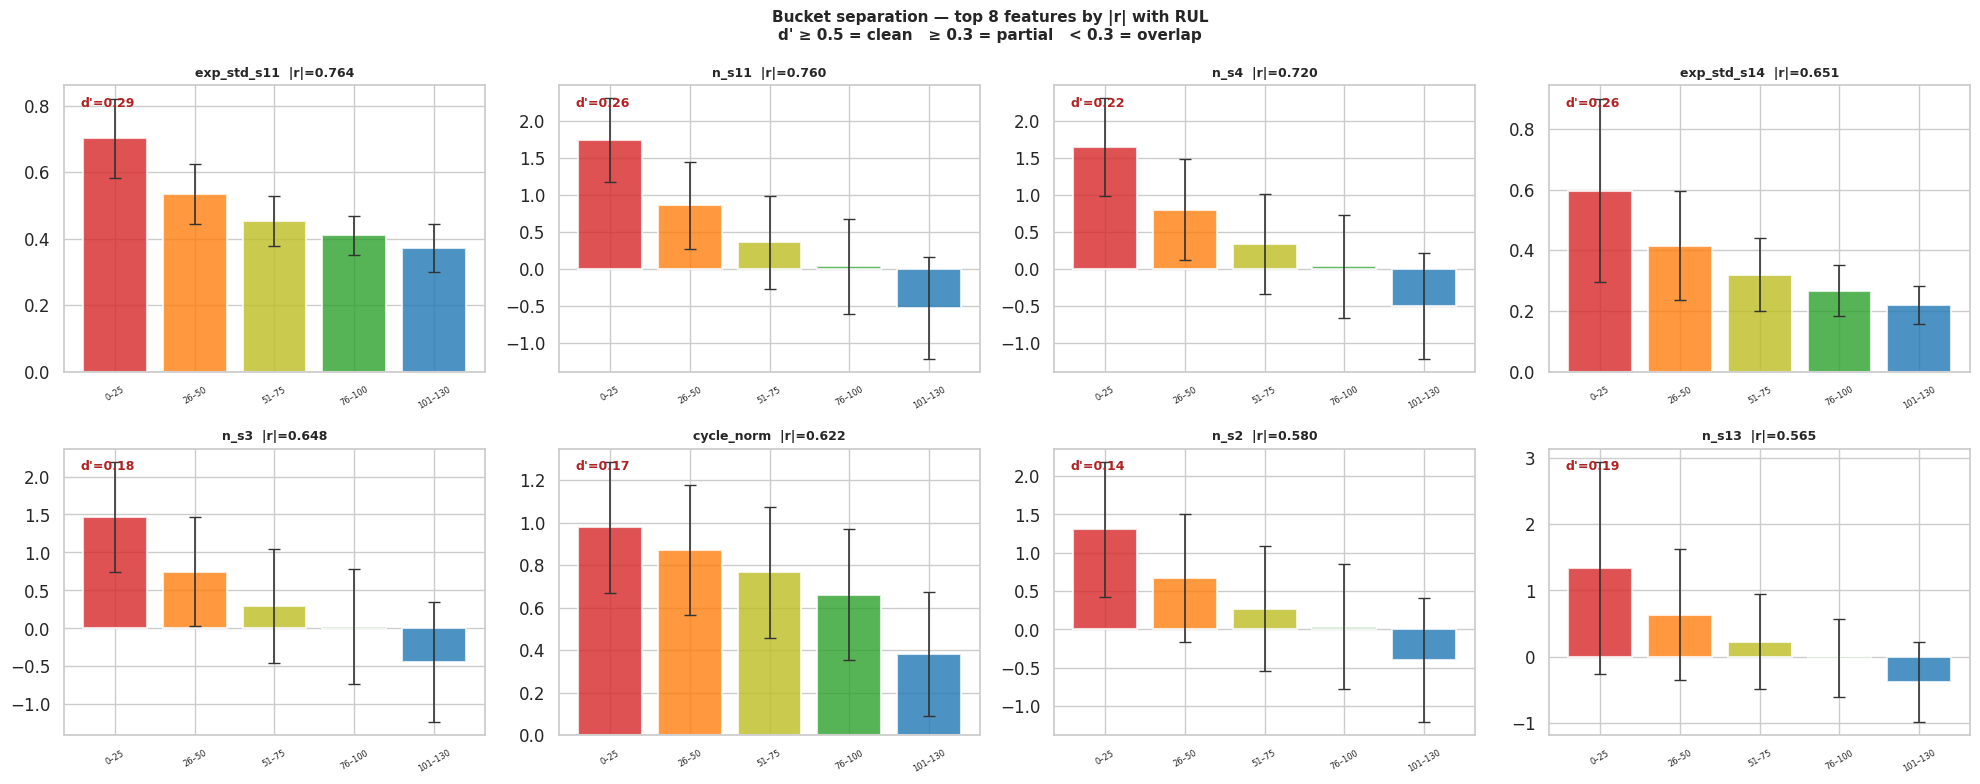

In [6]:
BUCKET_EDGES  = [0, 25, 50, 75, 100, 130]
BUCKET_LABELS = ['0–25', '26–50', '51–75', '76–100', '101–130']
BUCKET_COLORS = ['#d62728', '#ff7f0e', '#bcbd22', '#2ca02c', '#1f77b4']

r_feat = df[FINAL_FEATURES].corrwith(df['rul']).abs().sort_values(ascending=False)
TOP_8 = r_feat.head(8).index.tolist()

df['_bucket'] = pd.cut(df['rul'], bins=BUCKET_EDGES, labels=BUCKET_LABELS, include_lowest=True)
bm = df.groupby('_bucket', observed=True)[TOP_8].mean()
bs = df.groupby('_bucket', observed=True)[TOP_8].std()

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for idx, feat in enumerate(TOP_8):
    ax = axes.flatten()[idx]
    means, stds = bm[feat].values, bs[feat].values
    x = np.arange(len(means))
    ax.bar(x, means, color=BUCKET_COLORS, alpha=0.8, edgecolor='white', lw=1.5)
    ax.errorbar(x, means, yerr=stds, fmt='none', color='#333', capsize=4, lw=1.2)
    ax.set_xticks(x); ax.set_xticklabels(BUCKET_LABELS, fontsize=6, rotation=30)
    seps = [abs(means[i] - means[i+1]) / (stds[i] + stds[i+1] + 1e-9)
            for i in range(len(means) - 1)]
    worst = min(seps)
    col = 'green' if worst >= 0.5 else ('orange' if worst >= 0.3 else 'firebrick')
    ax.text(0.04, 0.96, f"d'={worst:.2f}", transform=ax.transAxes,
            fontsize=9, va='top', color=col, fontweight='bold')
    ax.set_title(f'{feat}  |r|={r_feat[feat]:.3f}', fontsize=9, fontweight='bold')

plt.suptitle("Bucket separation — top 8 features by |r| with RUL\n"
             "d' ≥ 0.5 = clean   ≥ 0.3 = partial   < 0.3 = overlap",
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()
df = df.drop(columns=['_bucket'])

## 6 · Window Construction & Scaling

Build sliding windows of length 40 from each engine's time series.
Scale with `RobustScaler(5,95)` and clip to ±5.  Save for the
forecast model notebook.

In [7]:
def make_windows(df_eng, window_size, step, channels):
    arr = df_eng[channels].values.astype(np.float32)
    rul = df_eng['rul'].values.astype(np.float32)
    T = len(arr)
    if T < window_size:
        pad = np.zeros((window_size - T, len(channels)), dtype=np.float32)
        arr = np.vstack([pad, arr])
        rul = np.concatenate([np.full(window_size - T, rul[0]), rul])
        T = window_size
    Xs, ys = [], []
    for start in range(0, T - window_size + 1, step):
        Xs.append(arr[start:start + window_size])
        ys.append(rul[start + window_size - 1])
    return np.stack(Xs), np.array(ys, dtype=np.float32)


def build_dataset(df_subset, window_size, step, channels):
    Xs, ys, uids = [], [], []
    for unit, grp in df_subset.sort_values('cycle').groupby('unit'):
        X_e, y_e = make_windows(grp, window_size, step, channels)
        Xs.append(X_e); ys.append(y_e); uids.extend([unit] * len(y_e))
    return np.concatenate(Xs), np.concatenate(ys), np.array(uids)


# ── Split ─────────────────────────────────────────────────────────────────────
all_units = sorted(df['unit'].unique())
rng = np.random.RandomState(SPLIT_SEED)
perm = rng.permutation(all_units)
holdout_units = perm[:N_HOLDOUT].tolist()
val_units     = perm[N_HOLDOUT:N_HOLDOUT + N_VAL].tolist()
train_units   = perm[N_HOLDOUT + N_VAL:].tolist()
print(f'Split seed={SPLIT_SEED}  →  train:{len(train_units)}  val:{len(val_units)}  holdout:{len(holdout_units)}')

df_train   = df[df.unit.isin(train_units)]
df_val     = df[df.unit.isin(val_units)]
df_holdout = df[df.unit.isin(holdout_units)]

X_train, y_train, uid_train       = build_dataset(df_train,   WINDOW_SIZE, STEP_TRAIN,   FINAL_FEATURES)
X_val, y_val, uid_val             = build_dataset(df_val,     WINDOW_SIZE, STEP_TRAIN,   FINAL_FEATURES)
X_holdout, y_holdout, uid_holdout = build_dataset(df_holdout, WINDOW_SIZE, STEP_HOLDOUT, FINAL_FEATURES)
N, T, C = X_train.shape

# ── Scale ─────────────────────────────────────────────────────────────────────
scaler = RobustScaler(quantile_range=(5, 95))
scaler.fit(X_train.reshape(-1, C))

def scale_X(X):
    N, T, C = X.shape
    return np.clip(scaler.transform(X.reshape(-1, C)).reshape(N, T, C).astype(np.float32),
                   -CLIP_VAL, CLIP_VAL)

X_train_sc   = scale_X(X_train)
X_val_sc     = scale_X(X_val)
X_holdout_sc = scale_X(X_holdout)

print(f'Train   : {X_train_sc.shape}   y mean={y_train.mean():.1f}')
print(f'Val     : {X_val_sc.shape}   y mean={y_val.mean():.1f}')
print(f'Holdout : {X_holdout_sc.shape}   y mean={y_holdout.mean():.1f}')

# ── Save ──────────────────────────────────────────────────────────────────────
out_path = PROCESSED / 'FD004_gru_train.npz'
np.savez_compressed(
    out_path,
    X_train=X_train_sc, y_train=y_train, uid_train=uid_train,
    X_val=X_val_sc, y_val=y_val, uid_val=uid_val,
    X_holdout=X_holdout_sc, y_holdout=y_holdout, uid_holdout=uid_holdout,
)
joblib.dump(scaler, GRU_DIR / 'gru_scaler.pkl')
meta = {
    'window_size': WINDOW_SIZE, 'step_train': STEP_TRAIN,
    'step_holdout': STEP_HOLDOUT, 'features': FINAL_FEATURES,
    'n_features': len(FINAL_FEATURES), 'rul_cap': RUL_CAP,
    'scaler': 'RobustScaler(5,95)+clip5', 'split_seed': SPLIT_SEED,
    'train_units': train_units, 'val_units': val_units,
    'holdout_units': holdout_units, 'fleet_median_life': FLEET_MEDIAN_LIFE,
}
joblib.dump(meta, GRU_DIR / 'gru_meta.pkl')
print(f'\nSaved {out_path.name}  ({out_path.stat().st_size / 1e6:.1f} MB)')
print(f'Features ({C}): {FINAL_FEATURES}')

# Bucket distribution
edges = [0, 26, 51, 76, 101, 131]
total = len(y_train)
print(f'\nTraining window bucket distribution:')
for lo, hi in zip(edges[:-1], edges[1:]):
    n = int(((y_train >= lo) & (y_train < hi)).sum())
    bar = '█' * int(40 * n / total)
    print(f'  RUL {lo:>3d}–{min(hi-1,130):<3d}  {n:>6,} windows  ({100*n/total:4.1f}%)  {bar}')

Split seed=33  →  train:199  val:25  holdout:25
Train   : (41614, 40, 26)   y mean=89.4
Val     : (4290, 40, 26)   y mean=80.5
Holdout : (151, 40, 26)   y mean=96.4

Saved FD004_gru_train.npz  (7.0 MB)
Features (26): ['cfd_s13', 'cycle_norm', 'exp_std_s11', 'exp_std_s14', 'exp_std_s2', 'exp_std_s3', 'exp_std_s7', 'exp_std_s8', 'n_s11', 'n_s13', 'n_s14', 'n_s15', 'n_s2', 'n_s3', 'n_s4', 'n_s7', 'os2', 'os3', 'slope_s11', 'slope_s13', 'slope_s14', 'slope_s15', 'slope_s2', 'slope_s3', 'slope_s4', 'slope_s7']

Training window bucket distribution:
  RUL   0–25    5,174 windows  (12.4%)  ████
  RUL  26–50    4,975 windows  (12.0%)  ████
  RUL  51–75    4,975 windows  (12.0%)  ████
  RUL  76–100   4,947 windows  (11.9%)  ████
  RUL 101–130  21,543 windows  (51.8%)  ████████████████████


## Summary

### Feature selection rationale

| Family | Action | Why |
|--------|--------|-----|
| `n_s*` | **Keep all 9** | Primary degradation signal after condition normalisation |
| `exp_std_s*` | **Keep (where independent)** | Engine-level accumulated volatility — grows as degradation progresses. The CNN sees 40-step windows but cannot compute engine-lifetime statistics. |
| `slope_s*` | **Keep** | Independent of n\_s\*, provides pre-computed rate-of-change signal |
| `roll_mean_s*` | **Dropped** | Near-duplicate of n\_s\* (r ≈ 0.97+); CNN can also learn smoothing |
| `os1/os2/os3` | **Keep** | Operating conditions (contextual) |
| `cycle_norm` | **Keep** | Life-stage proxy |
| `cfd_s*` | **Keep** | Fleet deviation for key sensors |

### Outputs
- `data/processed/FD004_gru_train.npz`
- `models/gru/gru_scaler.pkl`
- `models/gru/gru_meta.pkl`